<a href="https://colab.research.google.com/github/Qureshiii/MNIST-Image-Classification-Keras/blob/main/mnist_classification_ANN_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [69]:
(X_train, y_train),(X_test, y_test) = keras.datasets.mnist.load_data()

In [70]:
X_train.shape

(60000, 28, 28)

In [71]:
X_train[0].shape

(28, 28)

In [72]:
X_train = X_train/255
X_test = X_test/255

In [73]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [74]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [76]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9181 - loss: 0.2865 - val_accuracy: 0.9529 - val_loss: 0.1657
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9621 - loss: 0.1270 - val_accuracy: 0.9662 - val_loss: 0.1186
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9736 - loss: 0.0870 - val_accuracy: 0.9712 - val_loss: 0.0959
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9806 - loss: 0.0648 - val_accuracy: 0.9728 - val_loss: 0.0954
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9847 - loss: 0.0492 - val_accuracy: 0.9732 - val_loss: 0.0857
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9881 - loss: 0.0391 - val_accuracy: 0.9726 - val_loss: 0.0942
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9911 - loss: 0.0298 - val_accuracy: 0.9757 - val_loss: 0.0879
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9924 - loss: 0.0251 - 

In [77]:
y_prob = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [78]:
y_pred = y_prob.argmax(axis=1)

In [79]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

97.68

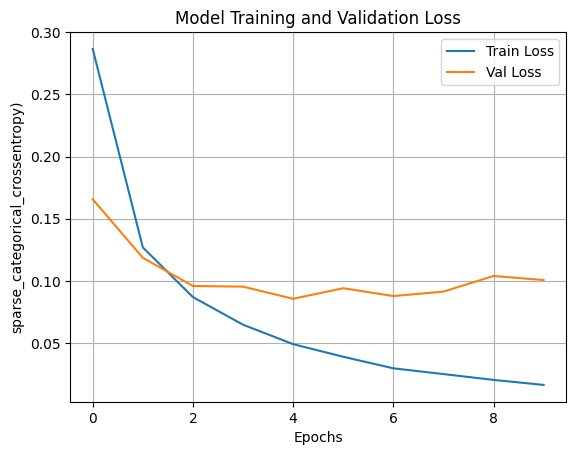

In [80]:
import matplotlib.pyplot as plt

# 🔄 Swapped out 'accuracy' for 'loss'
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.title('Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('sparse_categorical_crossentropy)')
plt.legend()
plt.grid(True)
plt.show()

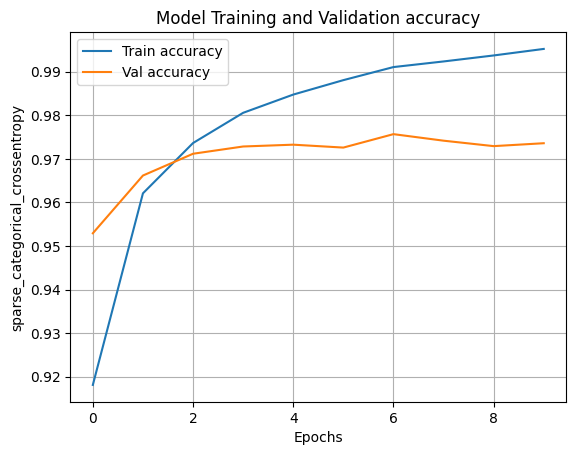

In [81]:
import matplotlib.pyplot as plt

# 🔄 Swapped out 'accuracy' for 'loss'
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')

plt.title('Model Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('sparse_categorical_crossentropy')
plt.legend()
plt.grid(True)
plt.show()